<a href="https://colab.research.google.com/github/kuppanagariadithya-boop/Analyzing-Google-play-Store-data/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT NECESSARY LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

UPLOAD ZIP FILE

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive(8).zip to archive(8).zip


EXTRACT ZIP FILE

In [3]:
with zipfile.ZipFile('archive(8).zip', 'r') as zip_ref:
    zip_ref.extractall()

CHECK FILE INSIDE FOLDER

In [4]:
import os
os.listdir()

['.config', 'archive(8).zip', 'datasets', 'sample_data']

LOAD DATASET

In [6]:
df = pd.read_csv("datasets/apps.csv")

df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


BASIC DATASET OVERVIEW

In [7]:
df.info()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

CHECK MISSING VALUES

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


DATA CLEANING

In [9]:
df.dropna(inplace=True)

CATEGORY DISTRIBUTION

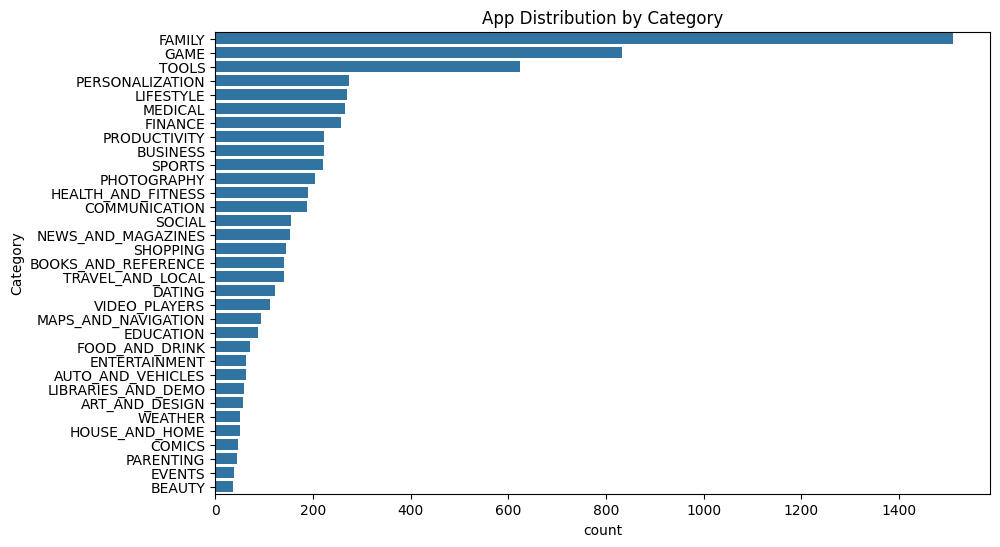

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)

plt.title("App Distribution by Category")

plt.show()

RATING DISTRIBUTION

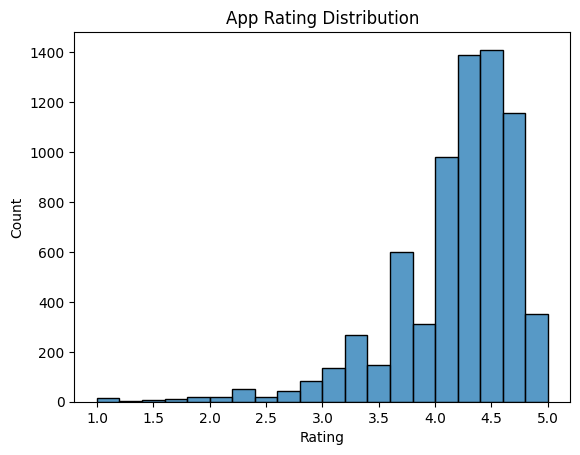

In [14]:
sns.histplot(df['Rating'], bins=20)

plt.title("App Rating Distribution")

plt.show()

FREE VS PAID APPS

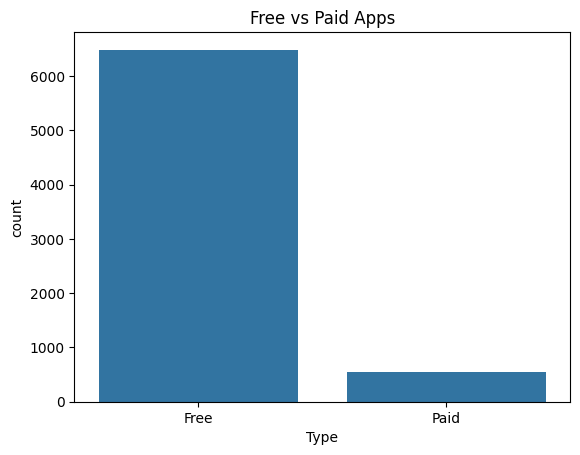

In [15]:
sns.countplot(x='Type', data=df)

plt.title("Free vs Paid Apps")

plt.show()

TOP CATEGORIES BY INSTALL

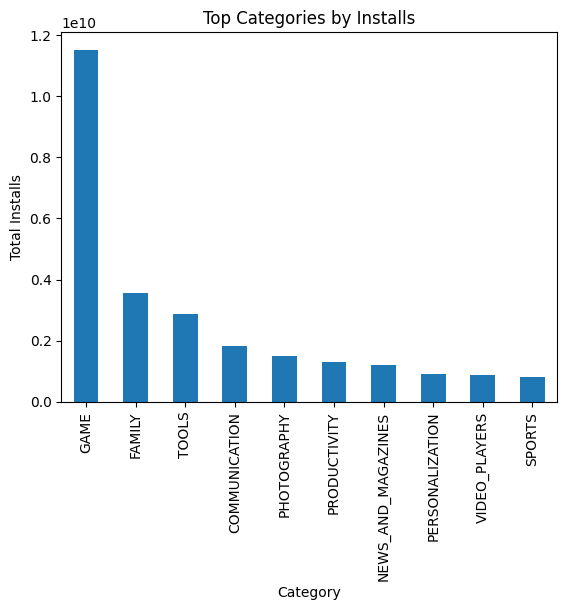

In [16]:
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)

category_installs.head(10).plot(kind='bar')

plt.title("Top Categories by Installs")

plt.ylabel("Total Installs")

plt.show()

CORRELATION HEATMAP

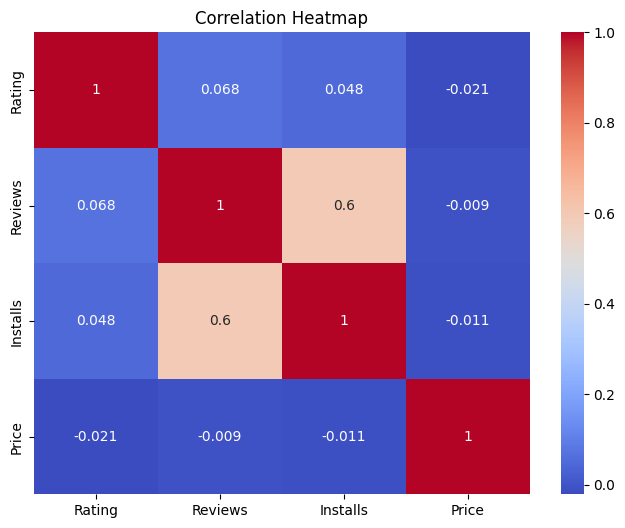

In [17]:
plt.figure(figsize=(8,6))

corr = df[['Rating','Reviews','Installs','Price']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

REVIEW VS RATING

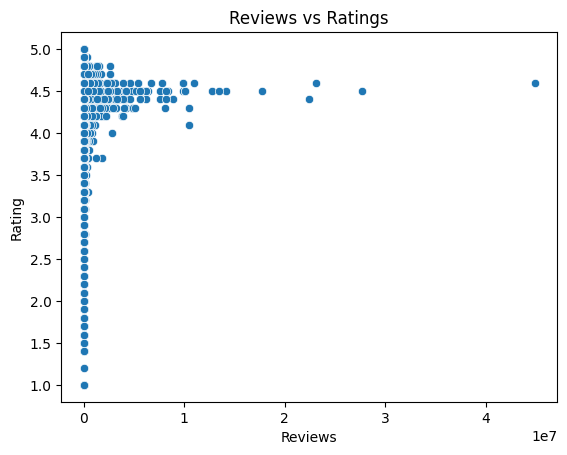

In [18]:
sns.scatterplot(x='Reviews', y='Rating', data=df)

plt.title("Reviews vs Ratings")

plt.show()

SAVE CLEANED DATASET

In [19]:
df.to_csv("cleaned_googleplaystore.csv", index=False)